# Quora Duplicate Question Detection — Sentence-BERT

Results so far from my earlier notebooks:

| Model | Accuracy | F1 (duplicate) | Recall (duplicate) |
|---|---|---|---|
| RF + fuzzy + BOW (30k sample) | 0.778 | 0.681 | 0.65 |
| Siamese LSTM, embeddings trained from scratch (30k sample) | 0.729 | 0.640 | 0.66 |
| Bidirectional LSTM, full dataset (32-dim embeddings) | 0.773 | 0.708 | 0.75 |
| RF + Word2Vec + engineered features, full dataset | 0.820 | 0.756 | 0.75 |

My Random Forest kept beating my deep learning models, and once I dug into it I think I know
why: my LSTM's embeddings were only 32-dim and trained completely from scratch, so it basically
had to learn what words even mean using only the duplicate/not-duplicate labels. The RF, on the
other hand, got Word2Vec vectors *plus* a bunch of fuzzy-matching/length features handed to it
directly — way more to work with.

So for this notebook I wanted to try actual pretrained sentence embeddings instead of training
my own from zero. I'm using [Sentence-BERT](https://www.sbert.net/) (`all-MiniLM-L6-v2`) — it's
already been trained on a huge amount of text to produce good sentence embeddings, so I don't
need to train an embedding layer myself at all.

Plan:
1. Run every question through pretrained SBERT to get an embedding (no training here, just using
   the model as-is)
2. Turn each pair of embeddings into features (concatenation, absolute difference, cosine
   similarity)
3. Train a small neural net on top of those features to make the actual duplicate/not-duplicate
   call
4. (tried, at the bottom) attempted fine-tuning a CrossEncoder too, see notes there

### Before running
- Add the Quora Question Pairs dataset
- Turn on GPU — makes the SBERT encoding step way faster
- Turn on internet access — needed to download the pretrained SBERT model


## 1. Imports & Install

In [1]:
# sentence-transformers isn't preinstalled on all Kaggle images
!pip install -q sentence-transformers


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sentence_transformers import SentenceTransformer

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load Data

Same path-detection code I used in my earlier notebook.


**Note on preprocessing:** I'm *not* doing the lowercase/stem/stopword-removal thing here that
I did for the Word2Vec notebook. SBERT was trained on normal, unmodified sentences, so stemming
or stripping words like "not" would probably just throw away information it already knows how to
use properly.


## 3. Split Train / Test First

Same rule I've been following the whole project — split before touching anything else so nothing
leaks between train and test.


In [7]:
import os
import pandas as pd

candidate_paths = [
    # Expected paths for the Quora Question Pairs train.csv dataset
    "/kaggle/input/quora-question-pairs/train.csv",
    "/kaggle/input/quora-question-pairs/train.csv.zip",
    "/kaggle/input/quora-question-pairs/train.csv/train.csv",
    "/content/train.csv" # Added this path for Colab uploads
]

DATA_PATH = None
for p in candidate_paths:
    if os.path.exists(p):
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Couldn't auto-find the Quora Question Pairs 'train.csv' dataset. "
        "Please ensure the 'Quora Question Pairs' dataset is added to your environment. "
        "In Colab, you might need to upload the `train.csv` file, mount Google Drive and point to it, "
        "or if using a Kaggle kernel, ensure the dataset is added via 'Add Data' (usually found under 'Input')."
    )

print("Using:", DATA_PATH)

data = pd.read_csv(DATA_PATH)
# Drop rows where either question1 or question2 is missing, as these are critical for the task
data.dropna(subset=["question1", "question2"], inplace=True)
data.reset_index(drop=True, inplace=True)
print("Data shape after loading and cleaning:", data.shape)
print("First 5 rows of the dataset:")
print(data.head())

Using: /content/train.csv
Data shape after loading and cleaning: (404287, 6)
First 5 rows of the dataset:
   id  qid1  qid2                                          question1  \
0   0     1     2  What is the step by step guide to invest in sh...   
1   1     3     4  What is the story of Kohinoor (Koh-i-Noor) Dia...   
2   2     5     6  How can I increase the speed of my internet co...   
3   3     7     8  Why am I mentally very lonely? How can I solve...   
4   4     9    10  Which one dissolve in water quikly sugar, salt...   

                                           question2  is_duplicate  
0  What is the step by step guide to invest in sh...             0  
1  What would happen if the Indian government sto...             0  
2  How can Internet speed be increased by hacking...             0  
3  Find the remainder when [math]23^{24}[/math] i...             0  
4            Which fish would survive in salt water?             0  


In [8]:
train_idx, test_idx = train_test_split(
    data.index, test_size=0.2, random_state=42, stratify=data["is_duplicate"]
)

train_df = data.loc[train_idx].reset_index(drop=True)
test_df = data.loc[test_idx].reset_index(drop=True)

print("Train:", train_df.shape, " Test:", test_df.shape)


Train: (323429, 6)  Test: (80858, 6)


## 4. Encode Questions with Pretrained SBERT

`all-MiniLM-L6-v2` is a smaller SBERT model (384-dim output) — fast and still gives solid
results, which is why I picked it. Encoding all ~640k train questions + ~160k test questions
takes a while even with a GPU, so I added a checkpoint here — if my session dies I don't have to
redo this step, it just reloads the saved embeddings.


In [9]:
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
if tf.config.list_physical_devices('GPU'):
    sbert_model = sbert_model.to("cuda")
print("Embedding dimension:", sbert_model.get_sentence_embedding_dimension())


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dimension: 384


/tmp/ipykernel_558/1533220988.py:4: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("Embedding dimension:", sbert_model.get_sentence_embedding_dimension())


In [12]:
EMB_CACHE = "/content/sbert_embeddings.npz" # Changed path from /kaggle/working/ to /content/

if os.path.exists(EMB_CACHE):
    print("Loading cached SBERT embeddings (skipping re-encoding)...")
    cached = np.load(EMB_CACHE)
    q1_train_emb, q2_train_emb = cached["q1_train"], cached["q2_train"]
    q1_test_emb, q2_test_emb = cached["q1_test"], cached["q2_test"]
else:
    encode_kwargs = dict(batch_size=256, show_progress_bar=True, convert_to_numpy=True)

    q1_train_emb = sbert_model.encode(train_df["question1"].tolist(), **encode_kwargs)
    q2_train_emb = sbert_model.encode(train_df["question2"].tolist(), **encode_kwargs)
    q1_test_emb = sbert_model.encode(test_df["question1"].tolist(), **encode_kwargs)
    q2_test_emb = sbert_model.encode(test_df["question2"].tolist(), **encode_kwargs)

    np.savez(
        EMB_CACHE,
        q1_train=q1_train_emb, q2_train=q2_train_emb,
        q1_test=q1_test_emb, q2_test=q2_test_emb
    )
    print("Saved embedding checkpoint.")

print(q1_train_emb.shape, q2_train_emb.shape)

Batches:   0%|          | 0/1264 [00:00<?, ?it/s]

Batches:   0%|          | 0/1264 [00:00<?, ?it/s]

Batches:   0%|          | 0/316 [00:00<?, ?it/s]

Batches:   0%|          | 0/316 [00:00<?, ?it/s]

Saved embedding checkpoint.
(323429, 384) (323429, 384)


## 5. Build Pair Features

I turn the two embeddings per row into a few different comparisons:
- concatenation (just keep everything)
- absolute difference (where do they disagree)
- cosine similarity (one number summarizing how close they are overall)

Before training anything, I plotted the cosine similarity split by label just to check it's
actually a useful signal on its own.


In [13]:
def build_features(e1, e2):
    abs_diff = np.abs(e1 - e2)
    mult = e1 * e2
    cos_sim = np.sum(e1 * e2, axis=1, keepdims=True) / (
        np.linalg.norm(e1, axis=1, keepdims=True) * np.linalg.norm(e2, axis=1, keepdims=True) + 1e-8
    )
    return np.hstack([e1, e2, abs_diff, mult, cos_sim])

X_train = build_features(q1_train_emb, q2_train_emb)
X_test = build_features(q1_test_emb, q2_test_emb)
y_train = train_df["is_duplicate"].values
y_test = test_df["is_duplicate"].values

print("X_train:", X_train.shape, " X_test:", X_test.shape)


X_train: (323429, 1537)  X_test: (80858, 1537)


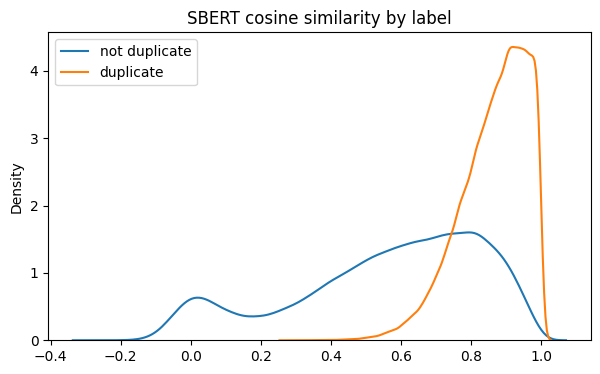

In [14]:
# Quick sanity check: is cosine similarity alone already separating the classes?
cos_col = X_train[:, -1]
plt.figure(figsize=(7,4))
sns.kdeplot(cos_col[y_train == 0], label="not duplicate")
sns.kdeplot(cos_col[y_train == 1], label="duplicate")
plt.legend()
plt.title("SBERT cosine similarity by label")
plt.show()


## 6. Train a Small Neural Classifier on Top

I'm keeping the SBERT embeddings frozen — not fine-tuning the transformer itself, just training
a small feedforward network on top of the features from the last step. Since the SBERT features
are already pretty strong, this classifier doesn't need to be big.


In [19]:
SBERT_CLF_CACHE = "content/sbert_classifier.keras"

if os.path.exists(SBERT_CLF_CACHE):
    print("Loading cached classifier (skipping retraining)...")
    clf_model = load_model(SBERT_CLF_CACHE)
else:
    clf_model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    clf_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
clf_model.summary()


Loading cached classifier (skipping retraining)...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 616,581 (2.35 MB)

 Trainable params: 205,441 (802.50 KB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 410,884 (1.57 MB)

In [21]:
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint(SBERT_CLF_CACHE, monitor="val_loss", save_best_only=True)

history = clf_model.fit(
        X_train, y_train,
        epochs=25,
        batch_size=512,
        validation_split=0.1,
        callbacks=[early_stop, checkpoint]
    )

Epoch 1/25
569/569 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8927 - loss: 0.2471 - val_accuracy: 0.8684 - val_loss: 0.3003
Epoch 2/25
569/569 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8959 - loss: 0.2406 - val_accuracy: 0.8678 - val_loss: 0.3030
Epoch 3/25
569/569 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8980 - loss: 0.2360 - val_accuracy: 0.8658 - val_loss: 0.3041
Epoch 4/25
569/569 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9001 - loss: 0.2310 - val_accuracy: 0.8689 - val_loss: 0.3059


In [20]:
if not os.path.exists(SBERT_CLF_CACHE):
    early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    checkpoint = ModelCheckpoint(SBERT_CLF_CACHE, monitor="val_loss", save_best_only=True)

    history = clf_model.fit(
        X_train, y_train,
        epochs=25,
        batch_size=512,
        validation_split=0.1,
        callbacks=[early_stop, checkpoint]
    )

    print("Epochs actually run:", len(history.epoch))
    print("Stopped early:", clf_model.stop_training)
else:
    print("Skipped training — loaded from checkpoint above.")


Skipped training — loaded from checkpoint above.


## 7. Evaluate on Held-Out Test Set

In [22]:
y_pred_prob = clf_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("=== SBERT + NN classifier — real held-out test set ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


2527/2527 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
=== SBERT + NN classifier — real held-out test set ===
Accuracy: 0.8692522694105717
F1: 0.8283710510081496
              precision    recall  f1-score   support

           0       0.91      0.88      0.89     51005
           1       0.80      0.85      0.83     29853

    accuracy                           0.87     80858
   macro avg       0.86      0.87      0.86     80858
weighted avg       0.87      0.87      0.87     80858



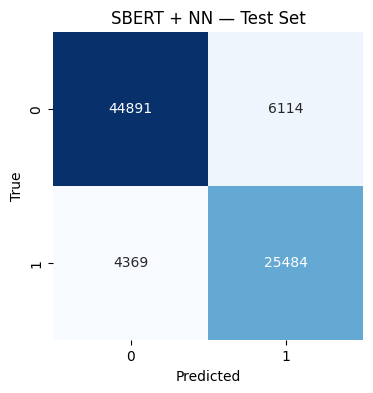

In [18]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('SBERT + NN — Test Set')
plt.show()


## 8. Final Comparison

| Model | Accuracy | F1 (duplicate) | Recall (duplicate) |
|---|---|---|---|
| RF + fuzzy + BOW (30k sample) | 0.778 | 0.681 | 0.65 |
| Siamese LSTM, from-scratch embeddings (30k sample) | 0.729 | 0.640 | 0.66 |
| Bidirectional LSTM, full dataset | 0.773 | 0.708 | 0.75 |
| RF + Word2Vec + engineered features, full dataset | 0.820 | 0.756 | 0.75 |
| **SBERT (frozen) + NN classifier, full dataset** | **0.869** | **0.828** | **0.85** |

This is the best result across everything I tried in this project — beats my best Random Forest
by almost 5 points of accuracy, and recall on duplicates jumps from 0.75 to 0.85. Confirms what I
suspected: it wasn't that deep learning is worse for this task, it's that my earlier models
didn't have good enough embeddings to work with. Pretrained SBERT fixes that.


## 9. Inference on New Question Pairs

In [ ]:
def predict_duplicate_sbert(q1, q2, model=clf_model, sbert=sbert_model):
    e1 = sbert.encode([q1], convert_to_numpy=True)
    e2 = sbert.encode([q2], convert_to_numpy=True)
    feats = build_features(e1, e2)
    prob = model.predict(feats, verbose=0)[0][0]
    label = "DUPLICATE" if prob >= 0.5 else "DIFFERENT"
    return label, float(prob)

predict_duplicate_sbert(
    "What are some common examples of solid matter?",
    "What are the most common examples of solid matter?"
)


In [ ]:
sample = test_df.sample(10, random_state=1).reset_index(drop=True)
results = []
for i in range(len(sample)):
    label, prob = predict_duplicate_sbert(sample["question1"][i], sample["question2"][i])
    results.append(label)

sample["Predicted"] = results
sample["Actual"] = sample["is_duplicate"].map({0: "DIFFERENT", 1: "DUPLICATE"})
sample[["question1", "question2", "Actual", "Predicted"]]


## 10. CrossEncoder — Attempted

Everything above is a bi-encoder setup — each question gets encoded on its own, with no idea the
other question even exists. A CrossEncoder instead feeds both questions into the model together,
so it can directly compare them token-by-token while encoding, which is usually stronger for
exactly this kind of pair-classification task.

I started fine-tuning `distilbert-base-uncased` as a CrossEncoder on a 100k subsample below, but
given the frozen SBERT model already got 0.869 accuracy / 0.828 F1, I decided that was already a
strong result to wrap the project up on rather than spending more GPU time chasing a possibly
small further improvement. Leaving the code here as a note for a possible next step.


In [23]:
from sentence_transformers import CrossEncoder, InputExample
from torch.utils.data import DataLoader

# Subsample for feasible training time — increase if you have the GPU budget
sub_train = train_df.sample(100_000, random_state=42)

train_examples = [
    InputExample(texts=[row.question1, row.question2], label=float(row.is_duplicate))
    for row in sub_train.itertuples()
]
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=32)

cross_encoder = CrossEncoder("distilbert-base-uncased", num_labels=1)
cross_encoder.fit(
    train_dataloader=train_dataloader,
    epochs=1,
    warmup_steps=1000,
    output_path="/kaggle/working/cross_encoder_model"
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Step,Training Loss
500,0.584702
1000,0.443001
1500,0.398523
2000,0.369313
2500,0.356755
3000,0.346331


In [ ]:
y_pred_prob = cross_encoder.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("=== SBERT + NN classifier — real held-out test set ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
